# Joint Fisher Forecast: PFS + DESI-DR2 BAO + BBN+$n_s$ ($\nu\Lambda$CDM)

Combined Fisher forecast from full-shape, BAO, and external-prior information:
- **PFS full-shape** $P_\ell(k) + B_0$ (7 redshift bins, $\ell = 0, 2, 4$, with AP effect)
- **DESI DR2 BAO** (13 data points across 7 redshift bins)
- **External priors**: BBN prior on $\omega_b$ and Gaussian prior on $n_s$

Neutrino mass $\Sigma m_\nu$ is **varied** around the fiducial $m_\nu = 0.06\,$eV.

**Forecast basis**: $(\omega_b, \omega_c, \log A, n_s, h, m_\nu)$ — 6 parameters after marginalising PFS survey parameters.

In [1]:
import os
from pathlib import Path

os.environ.setdefault('MPLCONFIGDIR', '/tmp/matplotlib-jaxptpolypol')
Path(os.environ['MPLCONFIGDIR']).mkdir(parents=True, exist_ok=True)

import matplotlib
%matplotlib inline
%config InlineBackend.figure_format = 'retina'
import matplotlib.pyplot as plt
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "sans-serif",
    "font.sans-serif": "Computer Modern",
    "font.size": 22,
})
import matplotlib.lines as mlines

import numpy as np
import jax
jax.config.update("jax_enable_x64", True)
import jax.numpy as jnp
from jax.scipy.linalg import inv

from ps_1loop_jax import background as bg

from jaxptpolypol.model import BispectrumTreeModel, CosmoEmulator, PS1LoopModel
from jaxptpolypol.params import (
    CosmoParams,
    FullShapeSurveyParams,
    pack_joint_params,
    pack_pk_params,
    unpack_joint_params,
    unpack_pk_params,
)
from jaxptpolypol.inference import (
    fisher_matrix,
    marginalize_fisher,
    marginalized_fisher_block,
    sigma_from_fisher,
    fixed_and_varied_indices,
    gaussian_prior_fisher,
    build_prior_sigmas,
    project_fisher_to_derived,
    fisher_diagnostics,
    format_fisher_diagnostics,
)
from jaxptpolypol.plotting import plot_contours, plot_Gaussian
from jaxptpolypol.theory import (
    build_bispectrum_triangles_from_k_grid,
    compute_fiducial_distances,
    make_gaussian_joint_covariance_fn,
    make_joint_pk_bk_fn,
)
from jaxptpolypol.priors import build_prior_sigmas_from_spec, load_prior_spec
from jaxptpolypol.bao import load_desi_dr2, bao_fisher_matrix, add_bao_to_fullshape_fisher
from jaxptpolypol.marginalization import make_lcdm_corner_specs, project_case_to_specs


## Configuration

In [2]:
# ── Unified fiducial cosmology (Planck 2018 TT,TE,EE+lowE+lensing+BAO) ──
FIDUCIAL = {
    'ombh2': 0.02242, 'omch2': 0.11933, 'logA': 3.047,
    'ns': 0.9665, 'h': 0.6766, 'tau': 0.0561, 'mnu': 0.06,
}

# ── PFS survey config ──
z_bins   = (0.7,  0.9,  1.1,  1.3,  1.5,  1.8,  2.2)
V_bins   = tuple(v * 1000.**3 for v in (0.59, 0.79, 0.96, 1.09, 1.19, 2.58, 2.71))
knl_bins = (0.52, 0.65, 0.82, 1.02, 1.29, 1.82, 2.88)
n_bar    = (3.06e-4, 9.61e-4, 9.75e-4, 6.54e-4, 3.40e-4, 2.02e-4, 3.51e-4)
n_zbins  = len(z_bins)

# ── Bispectrum / joint P+B config (matches fisher_multibin_*_AP_PB.ipynb) ──
K_PK_MIN, K_PK_MAX, N_K = 0.02, 0.20, 37
K_BK_MIN, K_BK_MAX = 0.02, 0.08
K_NL_RSD = 0.45
NUM_MU = NUM_PHI = 65
N_GL = 16
BB_POWER_MODEL = 'kaiser'   # C_BB from Kaiser P_ell; set '1loop' to reuse the 1-loop P_ell
BACKGROUND_MODE = 'direct'


# ── PFS emulator (mnu variant) ──
PFS_EMULATOR = '/Users/nguyenmn/cosmopower-jax-for-pfs/cosmology/jense2024/jense_2023_camb_mnu/networks/jense_2023_camb_mnu_Pk_lin.npz'

# ── BAO data ──
BAO_DATA_DIR = "../../ext_data/bao_data/desi_bao_dr2"

# ── Forecast basis ──
SHARED_KEYS = ('ombh2', 'omch2', 'logA', 'ns', 'h', 'mnu')
N_SHARED = len(SHARED_KEYS)
SHARED_LABELS = (r'$\omega_b$', r'$\omega_c$', r'$\log A$', r'$n_s$', r'$h$', r'$m_\nu$')
FIDUCIAL_SHARED = np.array([FIDUCIAL[k] for k in SHARED_KEYS])

# ── Priors (BBN + ns) ──
COSMO_PRIORS = {'ombh2': 0.00055, 'ns': 0.042}  # BBN + ns10 (DESI convention, arXiv:2411.12022)

print("Unified fiducial:", FIDUCIAL)
print("Forecast basis:", SHARED_KEYS)
print(f"Applied priors: ombh2 sigma={COSMO_PRIORS['ombh2']}, ns sigma={COSMO_PRIORS['ns']}")
MODEL_TITLE = r'$\nu\Lambda$CDM'

Unified fiducial: {'ombh2': 0.02242, 'omch2': 0.11933, 'logA': 3.047, 'ns': 0.9665, 'h': 0.6766, 'tau': 0.0561, 'mnu': 0.06}
Forecast basis: ('ombh2', 'omch2', 'logA', 'ns', 'h', 'mnu')
Applied priors: ombh2 sigma=0.00055, ns sigma=0.0042


## Part 1 — PFS Full-Shape Fisher

In [3]:
# ── Emulator and models (mnu variant) ──
pklin_emulator = CosmoEmulator(probe='custom_log', emulator_path=PFS_EMULATOR)
ps1loop_model = PS1LoopModel(do_irres=True)
bispectrum_model = BispectrumTreeModel(do_AP=True, k_nl_rsd=K_NL_RSD)

# ── Fiducial cosmology (PFS basis) ──
cosmo_dict = {
    'ombh2': FIDUCIAL['ombh2'], 'omch2': FIDUCIAL['omch2'],
    'logA':  FIDUCIAL['logA'],  'ns':    FIDUCIAL['ns'],
    'h':     FIDUCIAL['h'],
    'z':     0.7,       # placeholder; overridden per bin
    'A_b':   3.13, 'eta_b': 0.603, 'logT_AGN': 7.8,
    'mnu':   FIDUCIAL['mnu'],   # keep LAST: fixed_cosmo=[5,6,7,8] indexes z/A_b/eta_b/logT_AGN
}
cosmo = CosmoParams(cosmo_dict)

# ── Bias fitting functions (arXiv:1907.06666) ──
def b1z(z): return 0.9 + 0.4 * z
def b2z(z): return -0.704 - 0.208 * z + 0.183 * z**2 - 0.00771 * z**3
def bG2z(z): return -(2. / 7.) * (b1z(z) - 1.)
def bGamma3z(z): return (23. / 42.) * (b1z(z) - 1.)

def Dplusz(z):
    return float(bg.growth_factor(
        cosmo_dict['ombh2'], cosmo_dict['omch2'], cosmo_dict['h'], z, mnu=cosmo_dict['mnu'],
    ))

def c0z(z): return 25. * Dplusz(z)**2
def c2z(z): return 25. * Dplusz(z)**2
def c4z(z): return Dplusz(z)**2

# ── Survey parameters per bin (P + B blocks) ──
surveys = []
for i, (z, knl, nd) in enumerate(zip(z_bins, knl_bins, n_bar)):
    s = FullShapeSurveyParams(
        shared={
            'bias': {'b1': b1z(z), 'b2': b2z(z), 'bG2': bG2z(z), 'bGamma3': bGamma3z(z)},
            'stoch': {'P_shot': 1.0},
            'k_nl': knl, 'ndens': nd,
        },
        pk={
            'ctr': {'c0': c0z(z), 'c2': c2z(z), 'c4': c4z(z), 'cfog': knl**(-4)},
            'stoch': {'a0': 0., 'a2': 0.},
        },
        bk={
            'ctr': {'c1': 0.0},
            'stoch': {'B_shot': 1.0, 'A_shot': 1.0},
        },
    )
    surveys.append(s)

joint_survey_keys = surveys[0].joint_param_keys

# ── Pack parameters (cosmo + joint P+B survey blocks) ──
packed_params = pack_joint_params(cosmo, surveys)
n_cosmo_params = sum(cosmo.param_sizes)
n_survey_params = len(joint_survey_keys)
print(f"Total parameters: {packed_params.shape[0]} ({n_cosmo_params} cosmo + {n_survey_params}×{n_zbins} survey)")

# ── Fiducial distances ──
Hz_fid, DAz_fid = compute_fiducial_distances(cosmo, z_bins, mnu=cosmo_dict['mnu'])
for z, Hz_val, DAz_val in zip(z_bins, Hz_fid, DAz_fid):
    print(f"  z={z}: H(z)={Hz_val:.2f} km/s/Mpc, D_A(z)={DAz_val:.2f} Mpc")


Tried to load pickle file from pre-trained model, but failed.
This usually means that you have TF>=2.14, or that you are loading a model that was trained on PCA but loaded with the log (or viceversa), or that you are loading a non-standard model from the cosmopower-organization repo.
Falling back to the dictionary, in case this also fails or does not output the right shape make sure you ran the `convert_tf214.py` script, and that a `.npz` file exists among the trained models, and that you ran `pip install .`. Also make sure that you are asking for the right probe between `custom_log` and `custom_pca`.


Total parameters: 101 (10 cosmo + 13x7 survey)
  z=0.7: H(z)=100.75 km/s/Mpc, D_A(z)=1517.28 Mpc
  z=0.9: H(z)=113.67 km/s/Mpc, D_A(z)=1652.58 Mpc
  z=1.1: H(z)=127.83 km/s/Mpc, D_A(z)=1732.11 Mpc
  z=1.3: H(z)=143.10 km/s/Mpc, D_A(z)=1774.25 Mpc
  z=1.5: H(z)=159.38 km/s/Mpc, D_A(z)=1791.13 Mpc
  z=1.8: H(z)=185.51 km/s/Mpc, D_A(z)=1786.02 Mpc
  z=2.2: H(z)=223.19 km/s/Mpc, D_A(z)=1746.91 Mpc


In [4]:
# ── Differentiable joint P+B wrapper ──
joint_fn = make_joint_pk_bk_fn(
    pklin_emulator=pklin_emulator,
    ps1loop_model=ps1loop_model,
    bispectrum_model=bispectrum_model,
    cosmo_keys=cosmo.param_keys,
    cosmo_sizes=cosmo.param_sizes,
    survey_keys=joint_survey_keys,
    ap=True,
    z_bins=z_bins,
    Hz_fid=Hz_fid,
    DAz_fid=DAz_fid,
    n_gl=N_GL,
    num_mu=NUM_MU,
    num_phi=NUM_PHI,
    background_mode=BACKGROUND_MODE,
)
joint_cov_fn = make_gaussian_joint_covariance_fn(
    pklin_emulator=pklin_emulator,
    ps1loop_model=ps1loop_model,
    cosmo_keys=cosmo.param_keys,
    cosmo_sizes=cosmo.param_sizes,
    survey_keys=joint_survey_keys,
    ap=True,
    z_bins=z_bins,
    Hz_fid=Hz_fid,
    DAz_fid=DAz_fid,
    bb_power_model=BB_POWER_MODEL,
    n_gl=N_GL,
    background_mode=BACKGROUND_MODE,
)
jitted_joint_fn = jax.jit(joint_fn)

# ── k grid and bispectrum triangles (same dk; canonical triangles inside (K_BK_MIN, K_BK_MAX)) ──
k = jnp.linspace(K_PK_MIN, K_PK_MAX, N_K)
dk = float(k[1] - k[0])
n_k = int(k.shape[0])
triangles, triangle_dk = build_bispectrum_triangles_from_k_grid(
    k, k_min=K_BK_MIN, k_max=K_BK_MAX, dk=dk,
)
n_tri = int(triangles.shape[0])
print(f"P grid: n_k={n_k}, dk={dk:.5f}; B triangles in ({K_BK_MIN}, {K_BK_MAX}): {n_tri}")

# ── Jacobian of the joint data vector ──
jitted_joint_fn(packed_params, k=k, triangles=triangles).block_until_ready()  # JIT warmup
%time jac = jax.jacfwd(jitted_joint_fn, argnums=0)(packed_params, k=k, triangles=triangles)
print(f"Per-bin joint block: 3*{n_k} + {n_tri}; Jacobian shape: {jac.shape}")

# ── Joint Gaussian covariance (C_PP + C_BB; C_PB currently zero in the library) ──
gauss_cov = joint_cov_fn(
    packed_params,
    V_survey=V_bins,
    k=k,
    dk=dk,
    triangles=triangles,
    triangle_dk=triangle_dk,
)

# ── PFS P+B Fisher matrix ──
F_pfs_full = fisher_matrix(gauss_cov, jac)
print(f"PFS P+B Fisher shape: {F_pfs_full.shape}")


CPU times: user 7min 59s, sys: 6.65 s, total: 8min 6s
Wall time: 60 s
Jacobian shape: (1050, 101)


PFS Fisher shape: (101, 101)


## Part 2 — DESI DR2 BAO Fisher

In [5]:
bao_dr2 = load_desi_dr2("all", data_dir=BAO_DATA_DIR)
fiducial_cosmo = packed_params[:n_cosmo_params]

F_bao = bao_fisher_matrix(
    bao_dr2, fiducial_cosmo,
    cosmo_keys=cosmo.param_keys, cosmo_sizes=cosmo.param_sizes,
    mnu_fixed=cosmo_dict['mnu'],
)
F_pfs_bao_full = add_bao_to_fullshape_fisher(F_pfs_full, F_bao, n_cosmo=n_cosmo_params)

print(f"DESI DR2 BAO data points: {len(bao_dr2.data_points)}")
print(f"BAO Fisher shape: {F_bao.shape}")

DESI DR2 BAO data points: 13
BAO Fisher shape: (10, 10)


## Part 3 — External Priors (BBN + $n_s$)

In [6]:
prior_spec = load_prior_spec('eft_eq12_2405_02252')
prior_sigmas = build_prior_sigmas_from_spec(
    cosmo_keys=cosmo.param_keys,
    cosmo_sizes=cosmo.param_sizes,
    survey_keys=joint_survey_keys,
    n_bins=n_zbins,
    observable='joint',
    spec=prior_spec,
    cosmo_priors=COSMO_PRIORS,
)
F_prior = gaussian_prior_fisher(packed_params.shape[0], prior_sigmas)

F_pfs_prior_full = F_pfs_full + F_prior
F_pfs_bao_prior_full = F_pfs_bao_full + F_prior

print(f"Applied priors: ombh2 σ={COSMO_PRIORS['ombh2']}, ns σ={COSMO_PRIORS['ns']} (ns10), "
      "plus Eq. (12) EFT/stochastic priors from arXiv:2405.02252")


Applied priors: ombh2 sigma=0.00055, ns sigma=0.0042


## Part 4 — Marginalise PFS survey parameters

In [7]:
# ── Remove truly fixed parameters ──
fixed_cosmo = [5, 6, 7, 8]  # z, A_b, eta_b, logT_AGN
fixed_survey_keys = {('shared', 'k_nl', None), ('shared', 'ndens', None)}
fixed_survey_offsets = [i for i, key in enumerate(joint_survey_keys) if key in fixed_survey_keys]

fixed_idx, varied_idx = fixed_and_varied_indices(
    n_cosmo_params, n_survey_params, n_zbins, fixed_cosmo, fixed_survey_offsets,
)
print(f"Fixed: {len(fixed_idx)}, Varied: {len(varied_idx)}")

# ── Cosmo indices within the varied subvector ──
# nuLCDM varied cosmo: ombh2(0), omch2(1), logA(2), ns(3), h(4), mnu(9) → 6 params
cosmo_varied_global = [i for i in range(n_cosmo_params) if i not in fixed_cosmo]
cosmo_varied_marg = [list(varied_idx).index(i) for i in cosmo_varied_global]
n_pfs_cosmo = len(cosmo_varied_marg)
print(f"PFS varied cosmo params: {n_pfs_cosmo}, indices in marg vector: {cosmo_varied_marg}")

# ── Marginalise each case to cosmo-only ──
F_pfs_cosmo = marginalized_fisher_block(
    marginalize_fisher(F_pfs_full, varied_idx), cosmo_varied_marg,
)
F_pfs_bao_cosmo = marginalized_fisher_block(
    marginalize_fisher(F_pfs_bao_full, varied_idx), cosmo_varied_marg,
)
F_pfs_prior_cosmo = marginalized_fisher_block(
    marginalize_fisher(F_pfs_prior_full, varied_idx), cosmo_varied_marg,
)
F_pfs_bao_prior_cosmo = marginalized_fisher_block(
    marginalize_fisher(F_pfs_bao_prior_full, varied_idx), cosmo_varied_marg,
)
print(f"PFS cosmo-only Fisher shape: {F_pfs_cosmo.shape}")

Fixed: 18, Varied: 83
PFS varied cosmo params: 6, indices in marg vector: [0, 1, 2, 3, 4, 5]
PFS cosmo-only Fisher shape: (6, 6)


## Results

In [8]:
# ── Compute marginalized 1sigma constraints in the forecast basis ──
def safe_sigma(F):
    try:
        cov = np.linalg.inv(0.5 * (F + F.T))
        d = np.diag(cov)
        return np.where(d > 0, np.sqrt(d), np.inf)
    except np.linalg.LinAlgError:
        cov = np.linalg.pinv(0.5 * (F + F.T))
        d = np.diag(cov)
        return np.where(d > 0, np.sqrt(d), np.inf)

cases = {
    'PFS P+B':                 np.asarray(F_pfs_cosmo),
    'PFS P+B+BBN+ns':          np.asarray(F_pfs_prior_cosmo),
    'PFS P+B+BAO':             np.asarray(F_pfs_bao_cosmo),
    'PFS P+B+BAO+BBN+ns':      np.asarray(F_pfs_bao_prior_cosmo),
}
sigmas = {label: safe_sigma(F) for label, F in cases.items()}

header = f"{'Param':>8s}  {'Fiducial':>10s}"
for label in cases:
    header += f"  {label:>16s}"
print(header)
print("-" * len(header))
for i, key in enumerate(SHARED_KEYS):
    row = f"{key:>8s}  {FIDUCIAL_SHARED[i]:10.5g}"
    for label in cases:
        s = sigmas[label][i]
        row += f"  {s:16.5g}" if np.isfinite(s) else f"  {'---':>16s}"
    print(row)

   Param    Fiducial               PFS        PFS+BBN+ns           PFS+BAO    PFS+BAO+BBN+ns
--------------------------------------------------------------------------------------------
   ombh2     0.02242         0.0063558        0.00054744         0.0023524        0.00048017
   omch2     0.11933          0.018858          0.006975         0.0089321         0.0035863
    logA       3.047            1.0049           0.14499           0.53369           0.12448
      ns      0.9665           0.33743         0.0041996           0.20499          0.004196
       h      0.6766          0.028032         0.0057409         0.0063218         0.0044631
     mnu        0.06            1.6421            0.3349           0.68698           0.17627


In [9]:
# Projected constraints on standard parameters
def projected_sigmas_from_fisher(fisher, rcond=1e-12):
    fisher = np.asarray(fisher, dtype=float)
    fisher = 0.5 * (fisher + fisher.T)
    eigvals = np.linalg.eigvalsh(fisher)
    scale = max(float(np.max(np.abs(eigvals))) if eigvals.size else 0.0, 1.0)
    if np.count_nonzero(eigvals > rcond * scale) < fisher.shape[0]:
        return np.full(fisher.shape[0], np.inf)
    cov = np.linalg.inv(fisher)
    diag = np.diag(cov)
    return np.where(diag > 0.0, np.sqrt(diag), np.inf)

native_cosmo_keys = tuple(SHARED_KEYS)
selected_plot_specs = list(
    make_lcdm_corner_specs(
        native_cosmo_keys,
        pklin_emulator=pklin_emulator,
        mnu_name='mnu',
        mnu_fixed=float(cosmo_dict.get('mnu', 0.06)),
        fixed_cosmo_values=cosmo_dict,
    )
) + ['mnu']

selected_fisher_cases = []
for label, fisher_case in cases.items():
    projection = project_case_to_specs(
        fisher_case,
        FIDUCIAL_SHARED,
        np.arange(N_SHARED),
        native_cosmo_keys,
        selected_plot_specs,
    )
    selected_fisher_cases.append({'label': label, 'projection': projection})

selected_param_names = selected_fisher_cases[0]['projection'].plot_names
selected_param_labels = selected_fisher_cases[0]['projection'].plot_labels

print('Marginalized 1-sigma constraints for selected projected parameters')
print('=' * 110)
header = f"{'Parameter':>18s}  {'Fiducial':>12s}"
for case in selected_fisher_cases:
    header += f"  {case['label']:>18s}"
print(header)
print('-' * len(header))

for i, name in enumerate(selected_param_labels):
    fid = float(selected_fisher_cases[0]['projection'].fid_plot[i])
    sigma_vals = [
        float(projected_sigmas_from_fisher(case['projection'].fisher_plot)[i])
        for case in selected_fisher_cases
    ]
    row = f"{name:>18s}  {fid:12.5g}"
    for sigma in sigma_vals:
        row += f"  {sigma:18.5g}" if np.isfinite(sigma) else f"  {'---':>18s}"
    print(row)


Marginalized 1-sigma constraints for selected projected parameters
         Parameter      Fiducial                 PFS          PFS+BBN+ns             PFS+BAO      PFS+BAO+BBN+ns
----------------------------------------------------------------------------------------------------------------
        $\Omega_m$       0.31105            0.028035             0.02427           0.0084675           0.0083778
             $H_0$         67.66              2.8032             0.57409             0.63218             0.44631
        $\sigma_8$       0.81034             0.11059             0.02991            0.085809             0.02848
      $\sum m_\nu$          0.06              1.6421              0.3349             0.68698             0.17627


Text(0.5, 0.98, '$\\nu\\Lambda$CDM: PFS $P_k$ + DESI DR2 BAO + BBN+$n_s$')

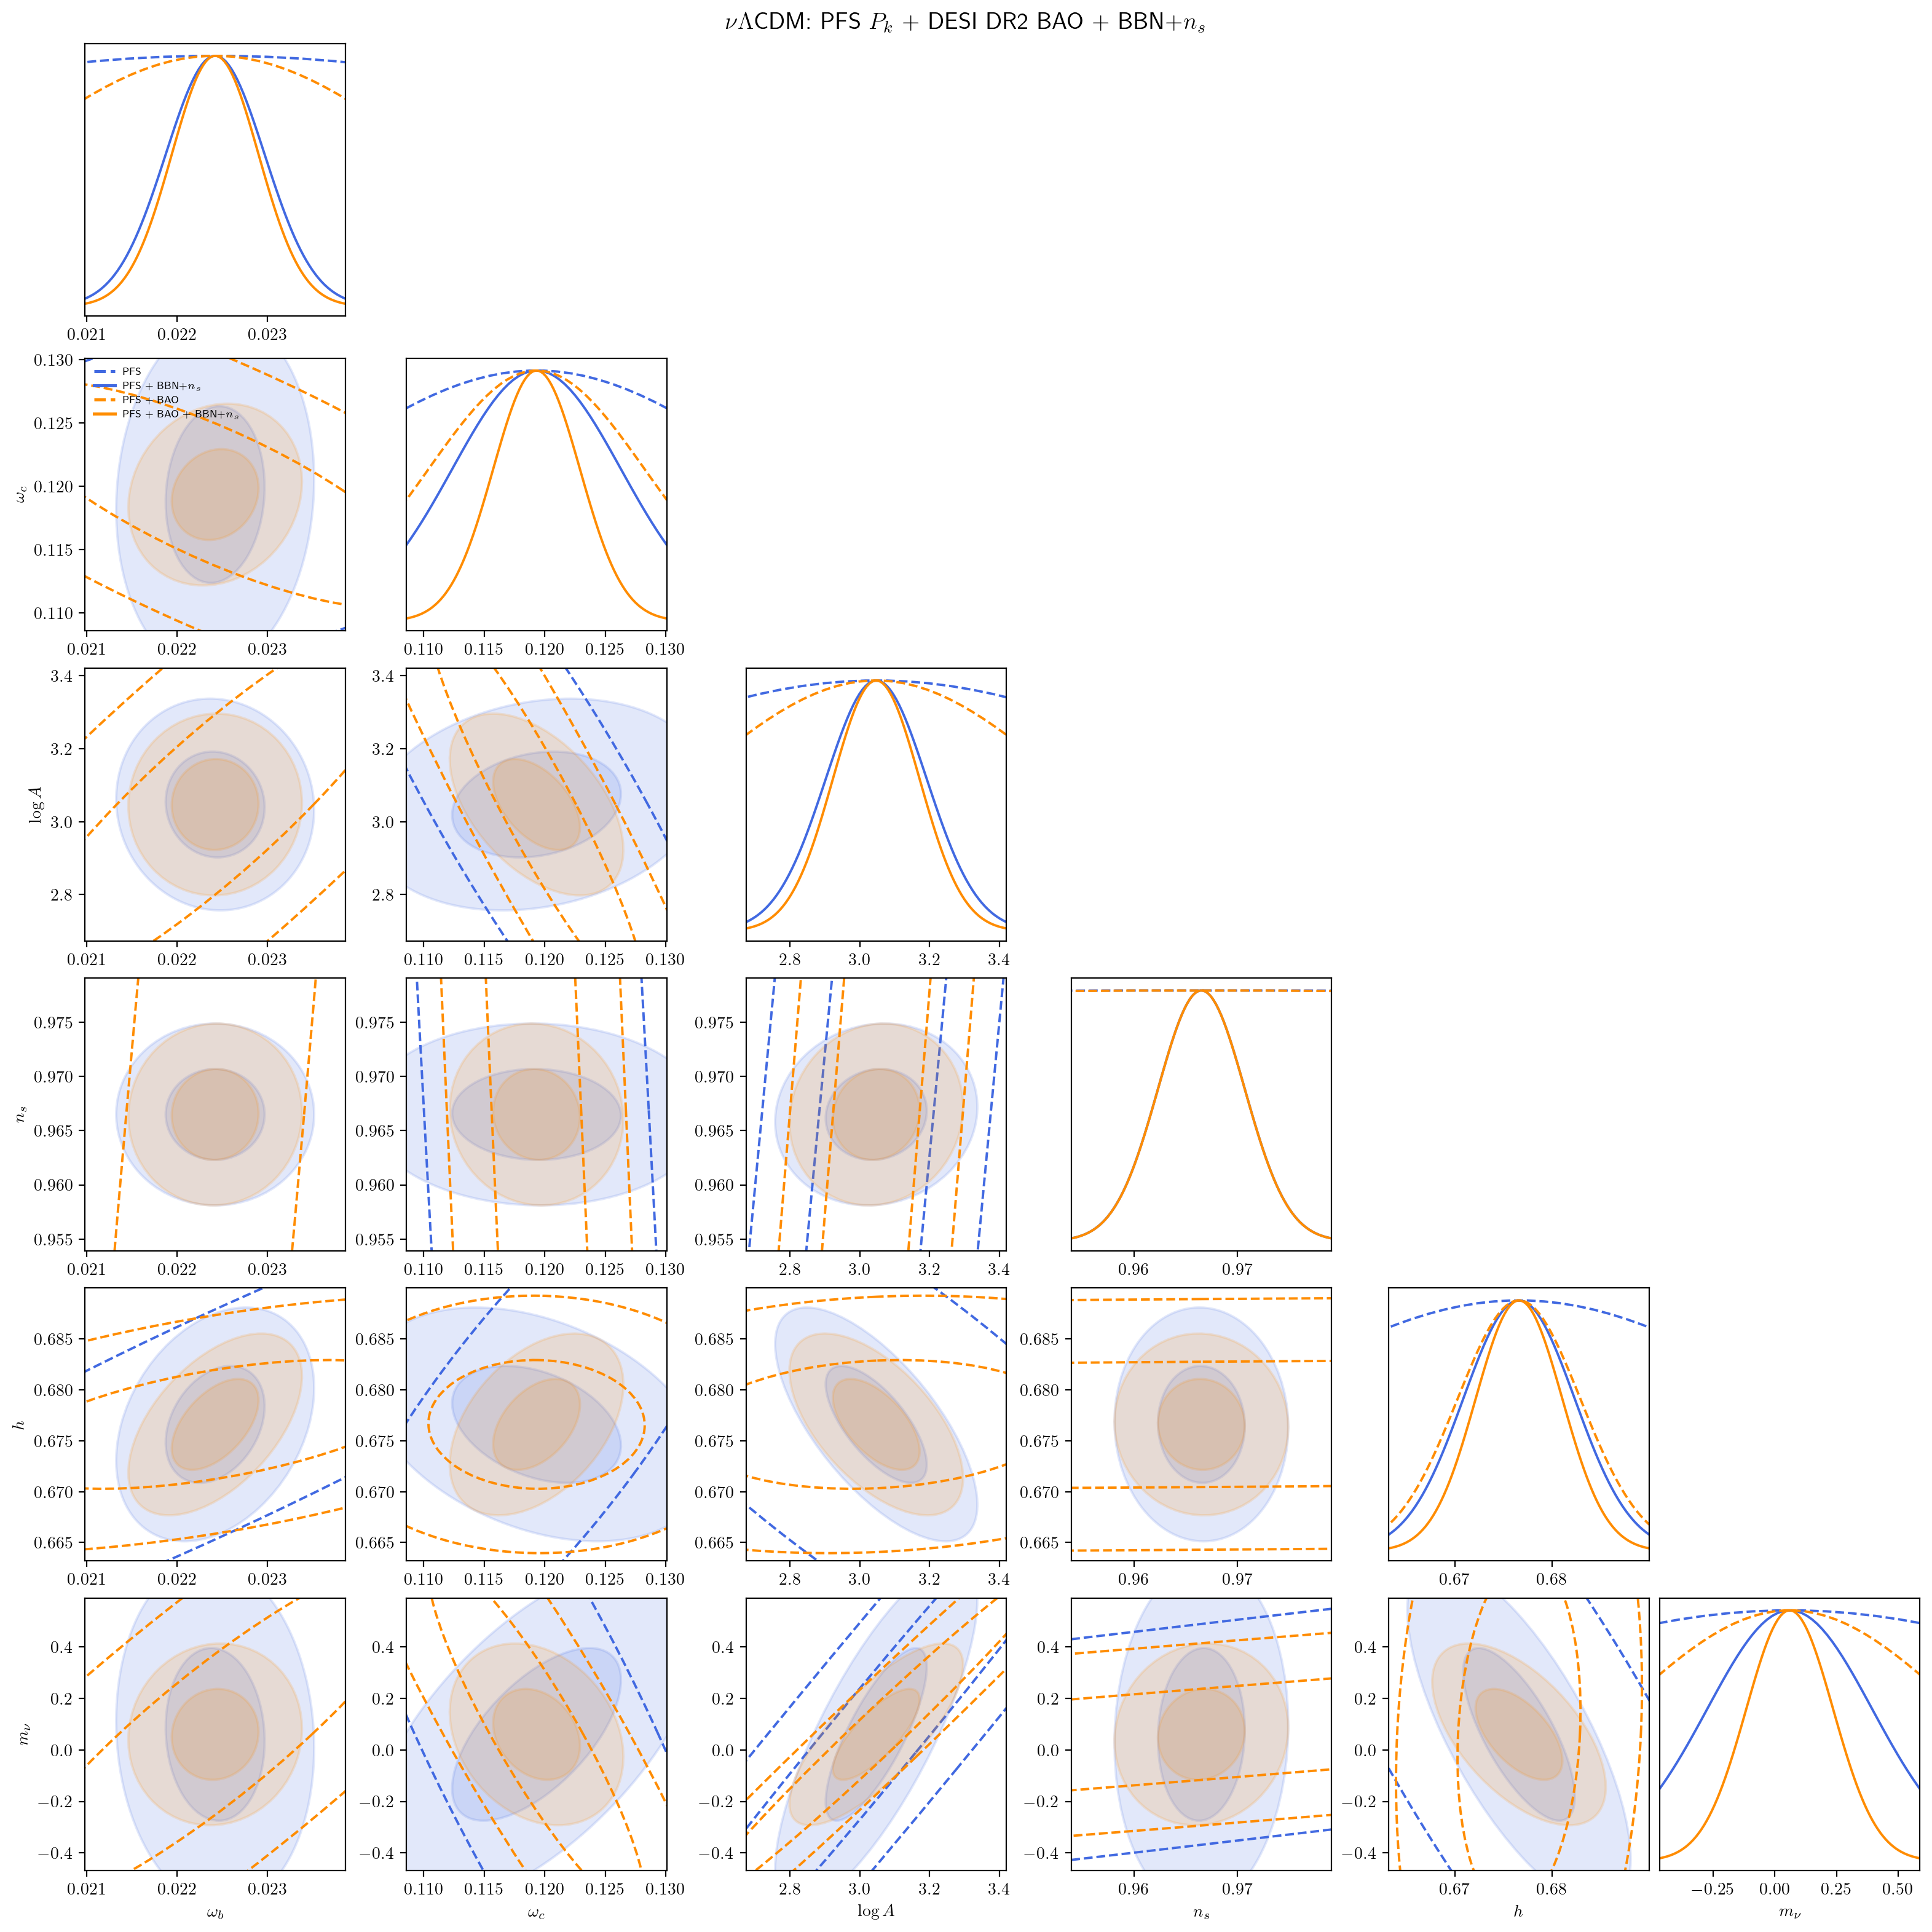

In [10]:
plot_cases = [
    (r'PFS',                     np.asarray(F_pfs_cosmo),           'royalblue',  '--', False),
    (r'PFS + BBN+$n_s$',         np.asarray(F_pfs_prior_cosmo),     'royalblue',  '-',  True),
    (r'PFS + BAO',               np.asarray(F_pfs_bao_cosmo),       'darkorange', '--', False),
    (r'PFS + BAO + BBN+$n_s$',   np.asarray(F_pfs_bao_prior_cosmo), 'darkorange', '-',  True),
]

plt.rcParams.update({"font.size": 10})
fig = plt.figure(figsize=(N_SHARED * 2.6, N_SHARED * 2.6), constrained_layout=True)

legend_handles = [
    mlines.Line2D([], [], color=c, ls=ls, lw=1.8, label=lbl)
    for lbl, _, c, ls, _ in plot_cases
]

for i in range(N_SHARED):
    for j in range(N_SHARED):
        ax = plt.subplot(N_SHARED, N_SHARED, i * N_SHARED + j + 1)

        if j < i:
            for label, F, color, ls, filled in plot_cases:
                sub = F[np.ix_([j, i], [j, i])]
                if np.linalg.matrix_rank(sub, tol=1e-10) < 2:
                    continue
                try:
                    plot_contours(
                        F, FIDUCIAL_SHARED, np.array([j, i]),
                        ax=ax, fill=filled, color=color, ls=ls, lw=1.4,
                        alpha=0.15 if filled else 1.0,
                    )
                except Exception:
                    pass
            if i == 1 and j == 0:
                ax.legend(handles=legend_handles, fontsize=6, frameon=False, loc='best')

        elif j == i:
            for label, F, color, ls, filled in plot_cases:
                if F[i, i] < 1e-10:
                    continue
                try:
                    plot_Gaussian(F, FIDUCIAL_SHARED, i, ax=ax, color=color, ls=ls, lw=1.4)
                except Exception:
                    pass
            ax.set_yticks([])

        else:
            ax.axis('off')

        if i == N_SHARED - 1:
            ax.set_xlabel(SHARED_LABELS[j])
        if j == 0 and i > 0:
            ax.set_ylabel(SHARED_LABELS[i])

fig.suptitle(
    MODEL_TITLE + r': PFS $P_\ell + B_0$ + DESI DR2 BAO + BBN+$n_s$',
    fontsize=14,
)

## Fisher diagnostics

In [11]:
print("PFS+BAO+BBN+ns Fisher diagnostics:")
print(format_fisher_diagnostics(fisher_diagnostics(np.asarray(F_pfs_bao_prior_cosmo), param_names=list(SHARED_KEYS))))
print()
print("PFS+BAO Fisher diagnostics:")
print(format_fisher_diagnostics(fisher_diagnostics(np.asarray(F_pfs_bao_cosmo), param_names=list(SHARED_KEYS))))

PFS+BAO+BBN+ns Fisher diagnostics:
rank=6/6, weak_modes=0, cond=3.726e+05, sym_err=0.000e+00, weak_tol=8.912e-04
smallest eigenvalues: 2.392e+01, 2.097e+02, 5.711e+04
null-space participation: mnu (0.71), logA (0.29)
mode 0 [smallest] eig=2.392e+01: mnu (+0.843), logA (+0.538), h (-0.013), omch2 (-0.006)
mode 1 [smallest] eig=2.097e+02: logA (+0.842), mnu (-0.538), omch2 (-0.022), h (-0.007)
mode 2 [smallest] eig=5.711e+04: ns (-0.997), h (-0.078), ombh2 (-0.008), omch2 (+0.003)

PFS+BAO Fisher diagnostics:
rank=6/6, weak_modes=0, cond=4.479e+06, sym_err=0.000e+00, weak_tol=5.658e-04
smallest eigenvalues: 1.263e+00, 1.859e+02, 5.008e+02
null-space participation: mnu (0.59), logA (0.36), ns (0.05)
mode 0 [smallest] eig=1.263e+00: mnu (+0.770), logA (+0.597), ns (+0.225), omch2 (-0.009)
mode 1 [smallest] eig=1.859e+02: logA (-0.730), mnu (+0.637), ns (-0.245), omch2 (+0.023)
mode 2 [smallest] eig=5.008e+02: ns (-0.941), logA (+0.332), h (-0.063), mnu (+0.018)
